# Рабочая тетрадь 5

Решены задания по теме объектно-ориентированного программирования, представления деревьев, бинарного дерева поиска и деревьев решений для классификации и регрессии.

Краткий чеклист:
- реализован класс тригонометрических функций;
- дерево с рисунка представлено списком из списков;
- реализовано бинарное дерево поиска с вставкой и печатью;
- построен классификатор `DecisionTreeClassifier` для двумерного набора данных;
- построена регрессионная модель `DecisionTreeRegressor` для данных о потреблении бензина.

In [2]:
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

WORKBOOK_DIR = Path.cwd()
RANDOM_STATE = 42
print(f'Рабочая папка ноутбука: {WORKBOOK_DIR.name}')

Рабочая папка ноутбука: Workbook_5


## 1. Класс для тригонометрических функций

Создаём небольшой класс-обёртку над функциями модуля `math`. Методы принимают аргумент в радианах, кроме отдельного метода `degrees_to_radians`, который переводит градусы в радианы.

In [3]:
class Trigonometry:
    def cos(self, x):
        return math.cos(x)

    def sin(self, x):
        return math.sin(x)

    def tan(self, x):
        return math.tan(x)

    def asin(self, x):
        return math.asin(x)

    def acos(self, x):
        return math.acos(x)

    def atan(self, x):
        return math.atan(x)

    def degrees_to_radians(self, degrees):
        return math.radians(degrees)

trig = Trigonometry()
angle_degrees = 45
angle_radians = trig.degrees_to_radians(angle_degrees)

trig_results = pd.DataFrame({
    'Операция': [
        'degrees_to_radians(45)', 'sin(pi/4)', 'cos(pi/4)', 'tan(pi/4)',
        'asin(sin(pi/4))', 'acos(cos(pi/4))', 'atan(1)'
    ],
    'Результат': [
        angle_radians,
        trig.sin(angle_radians),
        trig.cos(angle_radians),
        trig.tan(angle_radians),
        trig.asin(trig.sin(angle_radians)),
        trig.acos(trig.cos(angle_radians)),
        trig.atan(1),
    ],
})
trig_results

,Операция,Результат
0,degrees_to_radians(45),0.785398
1,sin(pi/4),0.707107
2,cos(pi/4),0.707107
3,tan(pi/4),1.000000
4,asin(sin(pi/4)),0.785398
5,acos(cos(pi/4)),0.785398
6,atan(1),0.785398


Для угла 45 градусов синус и косинус близки к `0.707`, тангенс равен `1`, а обратные функции возвращают угол в радианах.

## 2. Представление дерева списком из списков

На рисунке дерево имеет корень `a`, левое поддерево с корнем `b` и листьями `d`, `e`, а также правое поддерево с корнем `c` и листом `f`. Представим узел как список `[значение, левое_поддерево, правое_поддерево]`.

In [3]:
tree_as_lists = ['a', ['b', ['d'], ['e']], ['c', ['f']]]

root = tree_as_lists[0]
left_subtree = tree_as_lists[1]
right_subtree = tree_as_lists[2]

print('Корень дерева:', root)
print('Левое поддерево:', left_subtree)
print('Правое поддерево:', right_subtree)

Корень дерева: a
Левое поддерево: ['b', ['d'], ['e']]
Правое поддерево: ['c', ['f']]


## 3. Бинарное дерево поиска

Реализуем вставку без дублей. В формулировке тетради правое поддерево ошибочно описано как содержащее меньшие значения; для бинарного дерева поиска справа должны находиться значения больше текущего узла.

In [4]:
class Tree:
    def __init__(self, data):
        self.left = None
        self.right = None
        self.data = data

    def insert(self, value):
        if value == self.data:
            return False
        if value < self.data:
            if self.left is None:
                self.left = Tree(value)
                return True
            return self.left.insert(value)
        if self.right is None:
            self.right = Tree(value)
            return True
        return self.right.insert(value)

    def inorder(self):
        values = []
        if self.left is not None:
            values.extend(self.left.inorder())
        values.append(self.data)
        if self.right is not None:
            values.extend(self.right.inorder())
        return values

    def print_tree(self, level=0, branch='root'):
        indent = '  ' * level
        print(f'{indent}{branch}: {self.data}')
        if self.left is not None:
            self.left.print_tree(level + 1, 'L')
        if self.right is not None:
            self.right.print_tree(level + 1, 'R')

values = [12, 7, 15, 3, 9, 14, 18, 9, 1, 5]
bst = Tree(values[0])
insert_log = []
for value in values[1:]:
    insert_log.append({'value': value, 'inserted': bst.insert(value)})

print('Полная печать дерева:')
bst.print_tree()
print('\nОбход inorder:', bst.inorder())
pd.DataFrame(insert_log)

Полная печать дерева:
root: 12
  L: 7
    L: 3
      L: 1
      R: 5
    R: 9
  R: 15
    L: 14
    R: 18

Обход inorder: [1, 3, 5, 7, 9, 12, 14, 15, 18]


,value,inserted
0,7,True
1,15,True
2,3,True
3,9,True
4,14,True
5,18,True
6,9,False
7,1,True
8,5,True


Интерпретация: симметричный обход `inorder` возвращает значения в отсортированном порядке. Повторное значение `9` не добавляется, поэтому в дереве нет дублей.

## 4. Классификация деревом решений

Используем заданный двумерный набор данных. Дерево решений должно отделить объекты класса `0` с отрицательными координатами от объектов класса `1` с положительными координатами.

In [12]:
X = np.array([[-1, -1], [-2, -1], [-3, -2], [1, 1], [2, 1], [3, 2]])
y = np.array([0, 0, 0, 1, 1, 1])

clf = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=2)
clf.fit(X, y)
y_pred = clf.predict(X)

classification_metrics = pd.DataFrame({
    'Метрика': ['Accuracy'],
    'Значение': [accuracy_score(y, y_pred)],
})
print('Предсказания:', y_pred.tolist())
print('\nClassification report:')
print(classification_report(y, y_pred, zero_division=0))
classification_metrics

Предсказания: [0, 0, 0, 1, 1, 1]

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



,Метрика,Значение
0,Accuracy,1.0


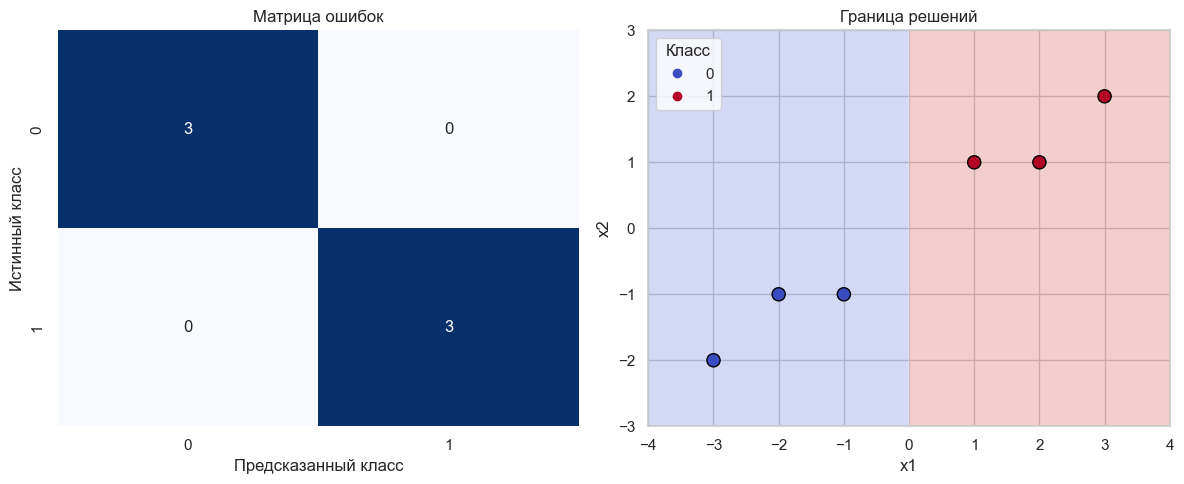

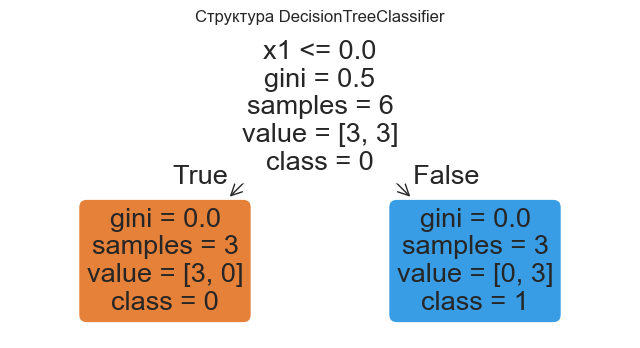

In [13]:
cm = confusion_matrix(y, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Матрица ошибок')
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
scatter = axes[1].scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='black', s=90)
axes[1].set_title('Граница решений')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].legend(*scatter.legend_elements(), title='Класс')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plot_tree(clf, feature_names=['x1', 'x2'], class_names=['0', '1'], filled=True, rounded=True)
plt.title('Структура DecisionTreeClassifier')
plt.show()

Интерпретация: accuracy равна 1.0, потому что учебный набор линейно разделим по признакам. Матрица ошибок не содержит внедиагональных ошибок.

## 5. Регрессия деревом решений

Используем данные о потреблении бензина из предыдущей рабочей тетради. Целевая переменная — `Petrol_Consumption`, остальные столбцы являются признаками. Если локального CSV нет, данные загружаются по URL из задания.

In [14]:
petrol_path = WORKBOOK_DIR.parent / 'Workbook_4' / 'petrol_consumption.csv'
petrol_url = 'https://raw.githubusercontent.com/likarajo/petrol_consumption/master/data/petrol_consumption.csv'

if petrol_path.exists():
    petrol_df = pd.read_csv(petrol_path)
    data_source = petrol_path.relative_to(WORKBOOK_DIR.parent)
else:
    petrol_df = pd.read_csv(petrol_url)
    data_source = petrol_url

print('Источник данных:', data_source)
print('Размер данных:', petrol_df.shape)
petrol_df.head()

Источник данных: Workbook_4/petrol_consumption.csv
Размер данных: (48, 5)


,Petrol_tax,Average_income,Paved_Highways,Population_Driver_licence(%),Petrol_Consumption
0,9.0,3571,1976,0.525,541
1,9.0,4092,1250,0.572,524
2,9.0,3865,1586,0.580,561
3,7.5,4870,2351,0.529,414
4,8.0,4399,431,0.544,410


In [15]:
X_reg = petrol_df.drop(columns=['Petrol_Consumption'])
y_reg = petrol_df['Petrol_Consumption']

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=RANDOM_STATE
)

regressor = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=4, min_samples_leaf=2)
regressor.fit(X_train, y_train)
y_pred_reg = regressor.predict(X_test)

regression_results = pd.DataFrame({
    'Фактическое': y_test.to_numpy(),
    'Прогноз': y_pred_reg,
    'Ошибка': y_test.to_numpy() - y_pred_reg,
}, index=y_test.index).sort_index()

metrics = pd.DataFrame({
    'Метрика': ['MAE', 'MSE', 'RMSE', 'R2'],
    'Значение': [
        mean_absolute_error(y_test, y_pred_reg),
        mean_squared_error(y_test, y_pred_reg),
        math.sqrt(mean_squared_error(y_test, y_pred_reg)),
        r2_score(y_test, y_pred_reg),
    ],
})
metrics

,Метрика,Значение
0,MAE,77.893750
1,MSE,9273.330584
2,RMSE,96.298134
3,R2,-0.152576


,Фактическое,Прогноз,Ошибка
3,414,467.333333,-53.333333
4,410,537.125000,-127.125000
8,464,537.125000,-73.125000
12,525,532.000000,-7.000000
19,640,871.666667,-231.666667
24,460,537.125000,-77.125000
25,566,537.125000,28.875000
26,577,537.125000,39.875000
27,631,586.800000,44.200000
37,704,586.800000,117.200000


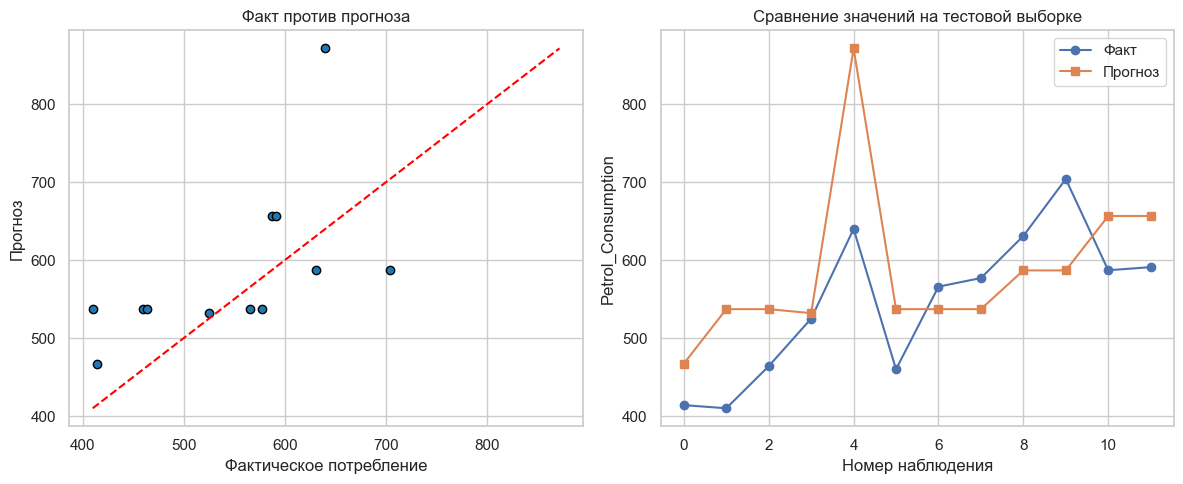

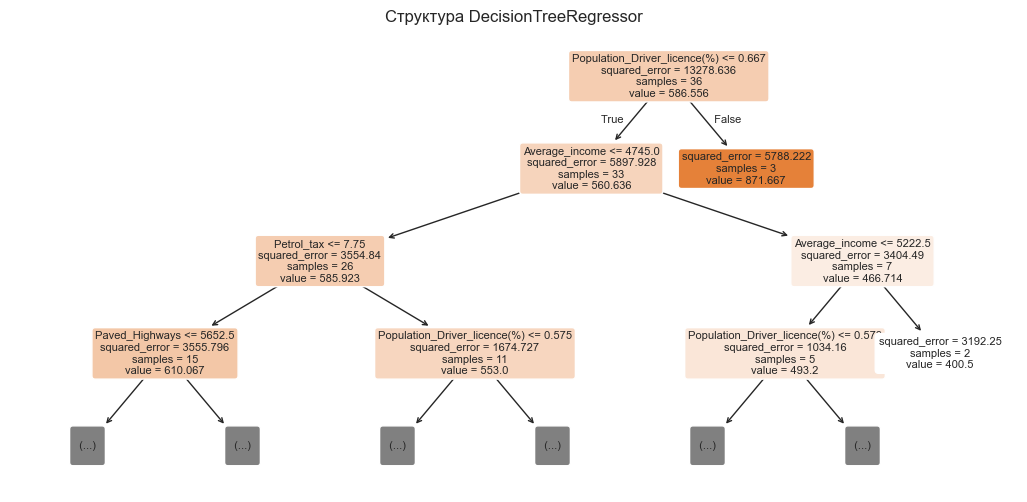

In [16]:
display(regression_results.head(12))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_pred_reg, color='tab:blue', edgecolor='black')
min_val = min(y_test.min(), y_pred_reg.min())
max_val = max(y_test.max(), y_pred_reg.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
axes[0].set_title('Факт против прогноза')
axes[0].set_xlabel('Фактическое потребление')
axes[0].set_ylabel('Прогноз')

ordered = regression_results.reset_index(drop=True)
axes[1].plot(ordered.index, ordered['Фактическое'], marker='o', label='Факт')
axes[1].plot(ordered.index, ordered['Прогноз'], marker='s', label='Прогноз')
axes[1].set_title('Сравнение значений на тестовой выборке')
axes[1].set_xlabel('Номер наблюдения')
axes[1].set_ylabel('Petrol_Consumption')
axes[1].legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 6))
plot_tree(
    regressor,
    feature_names=X_reg.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title('Структура DecisionTreeRegressor')
plt.show()

Интерпретация: MAE и RMSE показывают средний размер ошибки в единицах потребления бензина, а `R2` показывает долю объяснённой вариации. Дерево регрессии удобно тем, что строит кусочно-постоянный прогноз и не требует линейной зависимости между признаками и целевой переменной.